# 400 YouDo 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
r = np.full((20, 1000),fill_value=np.nan)
df = pd.read_csv('../ratings_long.csv')

for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

### Gözlemler ve Model Yaklaşımı

Derecelendirme matrisi 20x1000 boyutunda olmasına rağmen oldukça seyrektir. Verinin büyük çoğunluğu `NaN` olduğu için bu boşlukları doğrudan modele sokmak (imputation vs.) yerine, sadece bilinen (puanlanmış) veriler üzerinden hata hesaplayıp Gradient Descent ile Matrix Factorization uygulayacağız.

Ayrıca elimizdeki veri az ve modelin fazla parametresi olacağı için (20*K + 1000*K), aşırı öğrenmeyi (overfitting) engellemek adına maliyet fonksiyonuna L2 (Ridge) Regularization cezası ekleyeceğiz.

In [3]:
np.random.seed(42)

mask = ~np.isnan(r)
r_0 = np.nan_to_num(r)

print(f"Toplam puanlanmış film sayısı: {mask.sum()}")
print(f"Seyreklik Oranı: % {100 - (mask.sum() / (20*1000)) * 100}")

Toplam puanlanmış film sayısı: 200
Seyreklik Oranı: % 99.0


In [4]:
k = 4 # Latent feature sayısı
lr = 0.01 # Öğrenme oranı
lambd = 0.1 # L2 ceza parametresi
epochs = 3000

u = np.random.normal(0, 0.1, (20, k))
v = np.random.normal(0, 0.1, (k, 1000))

loss_degerleri = []

for i in range(epochs):
    tahmin = u @ v
    
    # Sadece puanlanmış değerlerdeki hataları alıyoruz
    hata = mask * (tahmin - r_0)
    
    # L2 cezalı Gradient hesaplamaları
    grad_u = (hata @ v.T) + lambd * u
    grad_v = (u.T @ hata) + lambd * v
    
    u -= lr * grad_u
    v -= lr * grad_v
    
    if i % 100 == 0:
        loss = np.sum(hata**2) + lambd * (np.sum(u**2) + np.sum(v**2))
        loss_degerleri.append(loss)
        if i % 500 == 0:
            print(f"Epoch: {i:4d} | Loss: {loss:.4f}")

Epoch:    0 | Loss: 2218.7453
Epoch:  500 | Loss: 41.6175
Epoch: 1000 | Loss: 40.6149
Epoch: 1500 | Loss: 40.1952
Epoch: 2000 | Loss: 39.9993
Epoch: 2500 | Loss: 39.8930


#### Eğitim Grafiği
Loss değerinin (Hata + L2 Penalty) epochlar boyunca nasıl azaldığını görebiliriz.

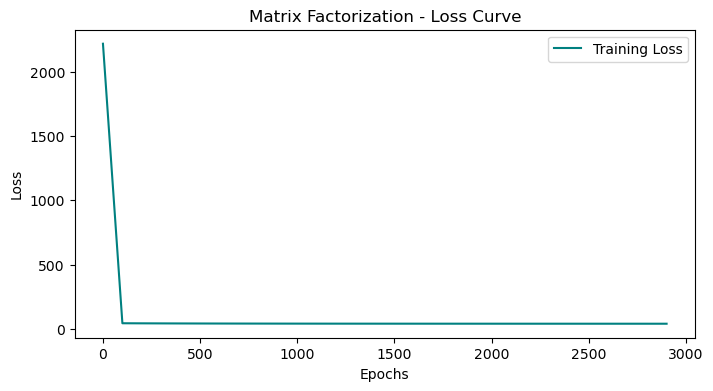

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(range(0, epochs, 100), loss_degerleri, label='Training Loss', color='teal')
plt.title("Matrix Factorization - Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Tahmin vs Gerçek Değerler Karşılaştırması
Modelin tahmin ettiği matrix (`r_tahmin = u @ v`) ile gerçek puanları kıyaslayalım.

In [6]:
r_tahmin = u @ v
gozlemler = np.argwhere(mask)

print(" Kullanıcı | Film  | Gerçek Puan | Tahmin")
print("-" * 45)

# Gözlemlerin içerisinden rastgele veya ilk 20 tanesini gösterelim
for idx in range(20):
    user, movie = gozlemler[idx]
    gercek = r[user, movie]
    tahmini = r_tahmin[user, movie]
    print(f"  User {user:2d}  | M {movie:4d} |     {gercek:.1f}     |  {tahmini:.2f}")

 Kullanıcı | Film  | Gerçek Puan | Tahmin
---------------------------------------------
  User  0  | M   16 |     5.0     |  4.98
  User  0  | M   72 |     5.0     |  4.96
  User  0  | M   86 |     5.0     |  4.96
  User  0  | M  259 |     1.0     |  0.99
  User  0  | M  319 |     4.0     |  3.97
  User  0  | M  521 |     4.0     |  3.97
  User  0  | M  534 |     2.0     |  1.99
  User  0  | M  671 |     1.0     |  0.99
  User  0  | M  673 |     2.0     |  1.98
  User  0  | M  739 |     3.0     |  2.97
  User  0  | M  764 |     2.0     |  1.98
  User  0  | M  798 |     3.0     |  2.97
  User  0  | M  917 |     4.0     |  3.97
  User  1  | M   87 |     1.0     |  0.99
  User  1  | M  125 |     5.0     |  4.97
  User  1  | M  129 |     1.0     |  0.99
  User  1  | M  148 |     1.0     |  0.99
  User  1  | M  248 |     2.0     |  1.99
  User  1  | M  261 |     2.0     |  1.99
  User  1  | M  286 |     5.0     |  4.97
